# IMDb Rating vs Meta Score Analysis

## Overview

This notebook investigates the relationship between IMDb Rating and Meta Score using the IMDb Top 1000 Movies dataset.

 To answer this question, we will:
 - handle missing values,
 - calculate the Pearson correlation coefficient,
 - examine mean IMDb Ratings across Meta Score ranges,
 - visualize the relationship and overall trend.

In [112]:

import pandas as pd
import matplotlib.pyplot as plt

## Research Question

**Is there a relationship between IMDb Rating and Meta Score?**

To answer this question, we will:
- handle missing values,
- calculate the correlation coefficient,
- visualize the relationship using a scatter plot.

## Data Loading

The IMDb Top 1000 Movies dataset is loaded into a Pandas DataFrame for analysis.

In [113]:
df = pd.read_csv("../data/imdb_top_1000.csv.xls")

## Missing Value Analysis

Before performing the analysis, the relevant variables are checked for missing values.

Missing values in `Meta_score` and `IMDB_Rating` are identified and their counts and percentages are calculated.

In [114]:
missing_value = pd.DataFrame({
    "Missing Count": df[["Meta_score", "IMDB_Rating"]].isnull().sum(),
    "Missing Value Percentage": (df[["Meta_score", "IMDB_Rating"]].isnull().sum() / len(df)) * 100
})

print(missing_value)

             Missing Count  Missing Value Percentage
Meta_score             157                      15.7
IMDB_Rating              0                       0.0


## Data Preparation

Rows with missing values in either `Meta_score` or `IMDB_Rating` are excluded from the analysis.

A separate DataFrame is created to preserve the original dataset while ensuring that only complete observations are used in the analysis.

In [115]:
analysis_df = df[df[["Meta_score", "IMDB_Rating"]].notnull().all(axis=1)].copy()

original_rows = len(df)
remaining_rows = len(analysis_df)

print(f"Original rows: {original_rows}")
print(f"Rows used for analysis: {remaining_rows}")
print(f"Rows excluded: {original_rows - remaining_rows}")

Original rows: 1000
Rows used for analysis: 843
Rows excluded: 157


## Correlation Analysis

Pearson's correlation coefficient is used to measure the strength and direction of the linear relationship between IMDb Rating and Meta Score.

The correlation is calculated using all available observations after missing values have been removed.

In [116]:
correlation = analysis_df["Meta_score"].corr(analysis_df["IMDB_Rating"])

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.269


A weak positive correlation indicates a relationship between IMDb Rating and Meta Score, but the relationship is not strong.


## Meta Score Binning

To make the relationship easier to interpret visually, Meta Scores are divided into intervals of 10 points.

For each `Meta Score` range, the mean `IMDb Rating` is calculated.

In [117]:
bins = [i for i in range(0, 101, 10)] 
labels = [f"{i}_{i + 10}" for i in range(0, 100, 10)]

analysis_df["Meta Score Binning"] = pd.cut(
    analysis_df["Meta_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [118]:
mean_rating = (
    (analysis_df.groupby("Meta Score Binning")["IMDB_Rating"]
    .mean()).round(2)
    .reset_index()
    .rename(columns={"IMDB_Rating": "Mean IMDB Rating"})
    )

print(mean_rating)

  Meta Score Binning  Mean IMDB Rating
0              20_30              7.65
1              30_40              7.77
2              40_50              7.78
3              50_60              7.85
4              60_70              7.88
5              70_80              7.90
6              80_90              7.95
7             90_100              8.07


## Visualization



### IMDb Rating vs Meta Score

The scatter plot shows the relationship between individual `IMDb Ratings` and `Meta Scores`.

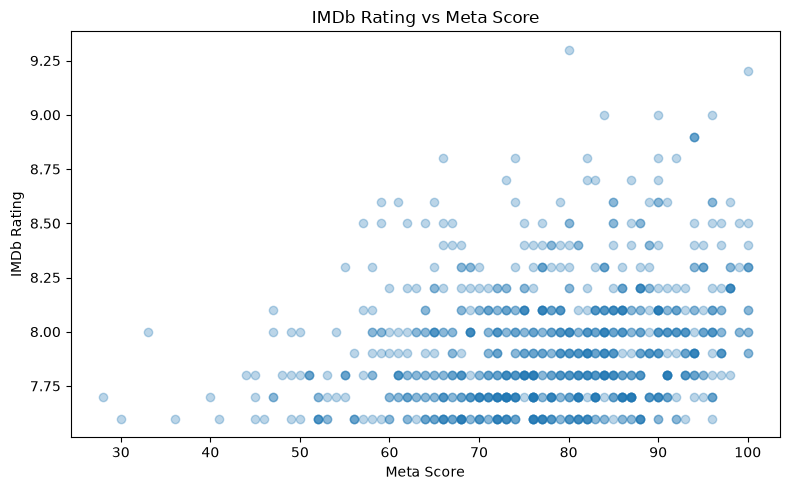

In [119]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    analysis_df["Meta_score"],
    analysis_df["IMDB_Rating"],
    alpha=0.3
)

ax.set_title("IMDb Rating vs Meta Score")
ax.set_xlabel("Meta Score")
ax.set_ylabel("IMDb Rating")

plt.tight_layout()
plt.show()

### Mean IMDb Rating by Meta Score Range

The line plot shows the `mean IMDb Rating` across different `Meta Score` ranges. 
Grouping Meta Scores helps highlight the overall trend in the data.

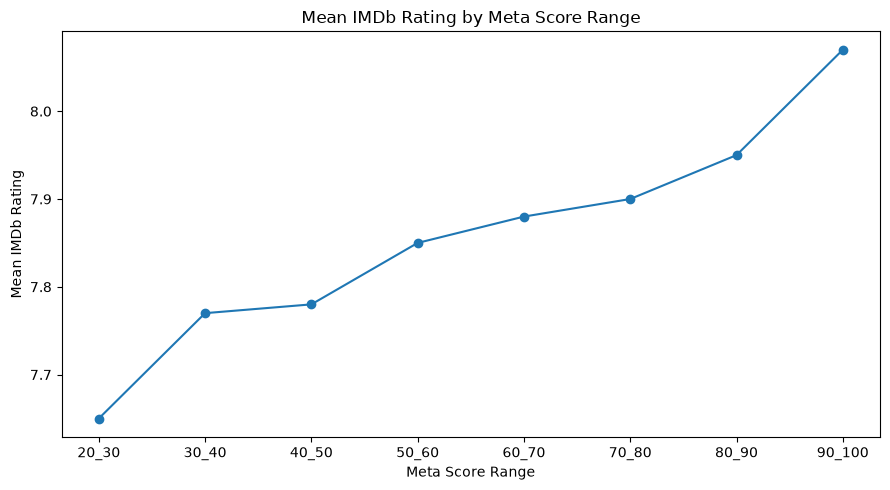

In [120]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    mean_rating["Meta Score Binning"],
    mean_rating["Mean IMDB Rating"],
    marker="o"
)

ax.set_title("Mean IMDb Rating by Meta Score Range")
ax.set_xlabel("Meta Score Range")
ax.set_ylabel("Mean IMDb Rating")

plt.tight_layout()
plt.show() 

## Conclusion

In this notebook, we analyzed the relationship between `IMDb Rating` and `Meta Score`.

Based on the results of this analysis, the relationship between IMDb Rating and Meta Score is weak and positive, and no Strong and clear pattern can be observed in the individual observations.

However, after binning the Meta Scores into 10-point ranges and calculating the average IMDb Rating for each range, we can see a clearer pattern in the relationship between Meta Score ranges and mean IMDb Rating.
